In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [2]:
df = pd.read_csv("../data/gym_churn.csv")
df.head()

,Member_ID,Name,Age,Gender,Address,Phone_Number,Membership_Type,Join_Date,Last_Visit_Date,Favorite_Exercise,Avg_Workout_Duration_Min,Avg_Calories_Burned,Total_Weight_Lifted_kg,Visits_Per_Month,Churn
0,1,NaN,19.0,Male,"Street 171, City 39",032-51510359,Quarterly,2022-07-23,2022-11-03,Pull-ups,93,214.0,13995.0,18.0,No
1,2,Shanza,19.0,Female,"Street 111, City 18",039-19243328,Monthly,2023-12-04,2024-02-14,Squats,37,436.0,4612.0,11.0,No
2,3,Ubaidullah,52.0,Male,"Street 69, City 21",033-60221501,Quarterly,2024-09-13,2024-12-07,Bench Press,98,523.0,3124.0,4.0,Yes
3,4,Mansoor Ahmed,52.0,Male,"Street 72, City 39",035-55527902,Monthly,2024-06-05,2025-02-24,Pull-ups,66,282.0,4586.0,24.0,No
4,5,Hanzala,32.0,Male,"Street 6, City 12",038-93946322,Monthly,2022-06-15,2022-12-02,Bench Press,32,522.0,16353.0,18.0,No


In [18]:
print("Shape:", df.shape)
df.info()

Shape: (89, 15)
<class 'pandas.DataFrame'>
Index: 89 entries, 1 to 149
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Member_ID                 89 non-null     int64  
 1   Name                      89 non-null     int64  
 2   Age                       89 non-null     float64
 3   Gender                    89 non-null     int64  
 4   Address                   89 non-null     int64  
 5   Phone_Number              89 non-null     int64  
 6   Membership_Type           89 non-null     int64  
 7   Join_Date                 89 non-null     int64  
 8   Last_Visit_Date           89 non-null     int64  
 9   Favorite_Exercise         89 non-null     int64  
 10  Avg_Workout_Duration_Min  89 non-null     int64  
 11  Avg_Calories_Burned       89 non-null     float64
 12  Total_Weight_Lifted_kg    89 non-null     float64
 13  Visits_Per_Month          89 non-null     float64
 14  Churn      

In [4]:
df.describe()

,Member_ID,Age,Avg_Workout_Duration_Min,Avg_Calories_Burned,Total_Weight_Lifted_kg,Visits_Per_Month
count,150.000000,137.000000,150.000000,139.000000,142.000000,138.000000
mean,75.500000,35.905109,73.326667,488.309353,9486.978873,14.224638
std,43.445368,11.654892,25.879560,168.649317,5127.955128,6.385451
min,1.000000,18.000000,30.000000,209.000000,1009.000000,4.000000
25%,38.250000,25.000000,53.000000,341.500000,5274.000000,8.000000
50%,75.500000,36.000000,74.000000,496.000000,9072.500000,14.000000
75%,112.750000,46.000000,94.500000,627.500000,13620.750000,20.000000
max,150.000000,54.000000,119.000000,788.000000,19722.000000,24.000000


In [5]:
df.isnull().sum()

Member_ID                    0
Name                        23
Age                         13
Gender                       0
Address                      0
Phone_Number                 0
Membership_Type              0
Join_Date                    9
Last_Visit_Date              0
Favorite_Exercise            0
Avg_Workout_Duration_Min     0
Avg_Calories_Burned         11
Total_Weight_Lifted_kg       8
Visits_Per_Month            12
Churn                        0
dtype: int64

In [6]:
df = df.dropna()

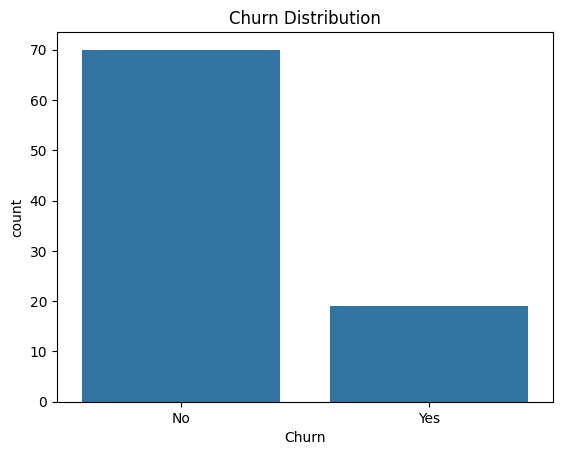

In [7]:
sns.countplot(x="Churn", data=df)
plt.title("Churn Distribution")
plt.savefig("../results/figures/churn_distribution.png")
plt.show()

In [8]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

/tmp/ipykernel_19328/4134231849.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


In [9]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [11]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier()
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    acc = accuracy_score(y_test, preds)
    report = classification_report(y_test, preds, output_dict=True)
    
    results.append({
        "Model": name,
        "Accuracy": acc,
        "F1 Score": report["weighted avg"]["f1-score"]
    })
    
    print(f"\n{name}")
    print(classification_report(y_test, preds))

/workspaces/CMPSC-446-Gym-Churn-Prediction/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Logistic Regression
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      1.00      1.00         3

    accuracy                           1.00        18
   macro avg       1.00      1.00      1.00        18
weighted avg       1.00      1.00      1.00        18


Decision Tree
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      1.00      1.00         3

    accuracy                           1.00        18
   macro avg       1.00      1.00      1.00        18
weighted avg       1.00      1.00      1.00        18


Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      1.00      1.00         3

    accuracy                           1.00        18
   macro avg       1.00      1.00      1.00        18
weighted avg       1.00

In [12]:
results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,F1 Score
0,Logistic Regression,1.0,1.0
1,Decision Tree,1.0,1.0
2,Random Forest,1.0,1.0


In [13]:
results_df.to_csv("../results/tables/model_comparison.csv", index=False)

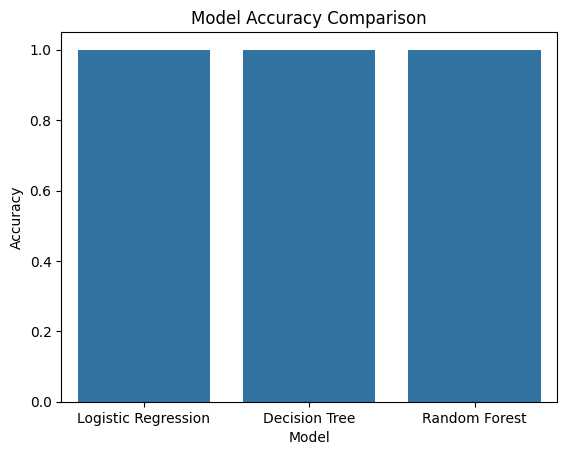

In [14]:
sns.barplot(x="Model", y="Accuracy", data=results_df)
plt.title("Model Accuracy Comparison")
plt.savefig("../results/figures/model_accuracy.png")
plt.show()

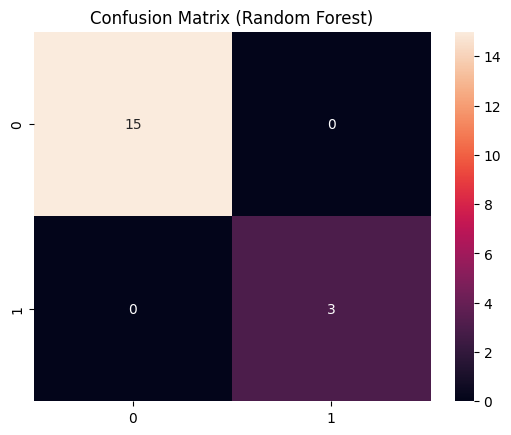

In [15]:
best_model = RandomForestClassifier()
best_model.fit(X_train, y_train)
preds = best_model.predict(X_test)

cm = confusion_matrix(y_test, preds)

sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix (Random Forest)")
plt.savefig("../results/figures/confusion_matrix.png")
plt.show()

In [ ]:
best_model = RandomForestClassifier()
best_model.fit(X_train, y_train)
preds = best_model.predict(X_test)

cm = confusion_matrix(y_test, preds)

sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix (Random Forest)")
plt.savefig("../results/figures/confusion_matrix.png")
plt.show()

In [16]:
importances = best_model.feature_importances_
features = X.columns

feat_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

feat_df

,Feature,Importance
13,Visits_Per_Month,0.550230
1,Name,0.062431
4,Address,0.059835
11,Avg_Calories_Burned,0.055075
0,Member_ID,0.051422
5,Phone_Number,0.045168
8,Last_Visit_Date,0.041802
10,Avg_Workout_Duration_Min,0.033930
7,Join_Date,0.026524
12,Total_Weight_Lifted_kg,0.023609


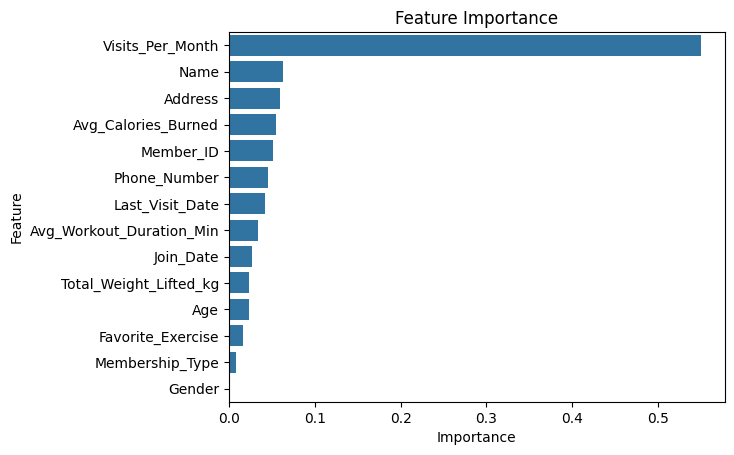

In [17]:
sns.barplot(x="Importance", y="Feature", data=feat_df)
plt.title("Feature Importance")
plt.savefig("../results/figures/feature_importance.png")
plt.show()